In [ ]:
!pip install caas_jupyter_tools

ERROR: Could not find a version that satisfies the requirement caas_jupyter_tools (from versions: none)
ERROR: No matching distribution found for caas_jupyter_tools


In [ ]:
import pandas as pd

# load patient_visits file
df = pd.read_csv('/content/patient_visits.csv')

# 1. Check for duplicate records
duplicates = df.duplicated().sum()


# 2. Check for missing data
#missing_data_per_column = df.isnull().sum()
#total_missing_records = (df.isnull().any(axis=1)).sum()
total_missing_records = (df.isnull().sum()).sum()

# 3. Check for illogical dates (visit_date before birth_date, or visit_date in future)
# Convert to datetime safely
df['visit_date'] = pd.to_datetime(df['visit_date'], errors='coerce')
df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')

illogical_dates = df[
    (df['visit_date'] < df['birth_date']) |
    (df['visit_date'] > pd.Timestamp.now())
].shape[0]

illogical_dates_NaT = df[
    (df['visit_date'].isna()) | # visit_date is missing/NaT
    (df['birth_date'].isna()) | # birth_date is missing/NaT

    (df['visit_date'] < df['birth_date']) |
    (df['visit_date'] > pd.Timestamp.now())
].shape[0]

# 4. Check for unrealistic measurements
unrealistic_height = df[(df['height_cm'] < 50) | (df['height_cm'] > 250)].shape[0]
unrealistic_weight = df[(df['weight_kg'] < 2) | (df['weight_kg'] > 300)].shape[0]

# Summarize results
results = pd.DataFrame({
    'Check': [
        'Duplicated records',
        'Records with missing data',
        'Illogical dates',
        'Illogical + missing dates',
        'Unrealistic height',
        'Unrealistic weight'
    ],
    'Count': [
        duplicates,
        total_missing_records,
        illogical_dates,
        illogical_dates_NaT,
        unrealistic_height,
        unrealistic_weight
    ]
})

# import caas_jupyter_tools
# caas_jupyter_tools.display_dataframe_to_user(name="Data Quality Audit Results", dataframe=results)

print(results)

                       Check  Count
0         Duplicated records     16
1  Records with missing data     79
2            Illogical dates     28
3  Illogical + missing dates     54
4         Unrealistic height     56
5         Unrealistic weight     63


In [ ]:
# 1. check duplicates
duplicates = df.duplicated().sum()

#2. check missing value cells
total_record_missing_rows = (df.isnull().any(axis=1)).sum() # = 76
total_record_missing_cells = df.isnull().sum().sum()  # = 79

#3. illogical dates (visit_date before birth_date, or visit_date in future)
# Convert to datetime
df['visit_date'] = pd.to_datetime(df['visit_date'], errors='coerce') # Any invalid or unparseable date is replaced with NaT (Not a Time = missing datetime).
df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')

illogical_dates = df[
    (df['visit_date'] < df['birth_date']) |
    (df['visit_date'] > pd.Timestamp.now())
].shape[0]

illogical_dates_NaT = df[
    (df['visit_date'].isna()) | # visit_date is missing/NaT
    (df['birth_date'].isna()) | # birth_date is missing/NaT

    (df['visit_date'] < df['birth_date']) |
    (df['visit_date'] > pd.Timestamp.now())
].shape[0]


#4. unrealistic measurements
# Reasonable range for humans: ~2 kg (newborn) to ~300 kg (severe obesity).
# Reasonable adult range: ~50 cm (very premature infants) to ~250 cm (world’s tallest people).
unrealistic_weight = df[(df['weight_kg'] < 2) | (df['weight_kg'] > 300)].shape[0]
unrealistic_height = df[(df['height_cm'] < 50) | (df['height_cm'] > 250)].shape[0]

# Summarize results
results = pd.DataFrame({
    'Check': [
        'Duplicated records',
        'Records/rows with missing data',
        'Cells missing data',
        'Illogical dates',
        'Illogical + missing dates',
        'Unrealistic height',
        'Unrealistic weight'
    ],
    'Count': [
        duplicates,
        total_record_missing_rows,
        total_record_missing_cells,
        illogical_dates,
        illogical_dates_NaT,
        unrealistic_height,
        unrealistic_weight
    ]
})

print(results)


                            Check  Count
0              Duplicated records     16
1  Records/rows with missing data     76
2              Cells missing data     79
3                 Illogical dates     28
4       Illogical + missing dates     54
5              Unrealistic height     56
6              Unrealistic weight     63


Scenario 2: Crib Complaints
Consider a company that manufactures products for babies and young children. The
company notices that there have been thousands of complaints on social media about its
new crib. These complaints state that the crib is prone to sudden collapse.
The company’s leadership is horrified at the thought of its products potentially causing
injuries to babies, and so it prepares to issue an urgent recall notice. But, a recently-hired
data scientist, Gretchen, takes a closer look at these social media complaints and advises
against the recall. Do you agree with the management or Gretchen? Examine
crib_complaints.csv and justify your answer.

In [ ]:
import pandas as pd

# load crib complaints file
df = pd.read_csv('/content/crib_complaints.csv')

# check for num of duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}\n")

# remove duplicates from the dataframe
df = df.drop_duplicates()

#checking what complaints is most common
complaint_counts = df['complaint_text'].value_counts()
print(complaint_counts)

top_6_sum = df['complaint_text'].value_counts().head(6).sum()
print(f"\nNum of 6 major safety complaints : {top_6_sum}")
print(f"\nPercentage ofmajor safety complaints : {100*top_6_sum/df.shape[0]}")

# Agree with management
# Complaints mostly about unsafely built product.
# Only a few complaints about cosmetics or customer experience
# but mostly about safety, so needs recall.



Number of duplicates: 23

complaint_text
This crib collapsed suddenly!                                          690
Do NOT buy this crib! It falls apart.                                  105
Unsafe crib - collapsed with baby inside!                               76
Worst crib ever, it collapsed instantly.                                76
My baby fell when the crib collapsed!                                   73
The crib design could be sturdier.                                      39
Minor wobble but otherwise okay.                                        37
Some assembly parts were missing.                                       34
Not happy with the paint finish.                                        31
Customer service was helpful with my concern.                           26
Some assembly parts were missing. Contacted support.                     3
Customer service was helpful with my concern. Awaiting replacement.      3
The crib design could be sturdier. Contacted support.      

Challenge
Find data quality issues in synthetic_data_1.csv. Note, that in addition to outliers, missing
values, duplicates, and so on, some of the labels in this dataset are incorrect. Implement a
strategy to detect noisy labels.


Ans:
- labels in this dataset are incorrect.
- detect noisy labels based on anomaly detection.
- we can train a classifier on the data and use the classifier to predict labels on the same data.
- samples where where the predicted label differs from the given label — these are potential noisy labels.

-- IMP - train-test split to avoid overfitting

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('synthetic_data_1.csv')

# Print the first 5 rows (default)
print(df.head())
print('\n')

# Encode labels to numbers
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

# Features and target
X = df[['X1', 'X2']]
y = df['label_enc']

X_train = X
y_train = y

# Split to train/test (optional but recommended to avoid overfitting)
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.3, random_state=42
)

# Train classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict on entire dataset (or test set)
y_pred = clf.predict(X)

# Identify mismatches (potential noisy labels)
mismatches = df[y_pred != y]

print("Potential noisy label samples:")
print(mismatches)

# Optionally, show mismatch count
print(f"Number of potential noisy labels: {len(mismatches)}")


         X1        X2 label
0  0.478563  4.426634   mid
1  3.482346  1.430697   mid
2  1.846456  1.211099   low
3  3.524794  4.976792  high
4  1.593832  3.459851  high


Potential noisy label samples:
           X1        X2 label  label_enc
4    1.593832  3.459851  high          0
10   3.305839  0.245486   mid          2
18   2.086455  4.945173  high          0
36   4.296945  4.107521  high          0
40   0.529542  0.654475   mid          2
83   3.961497  2.593583   mid          2
96   2.141736  1.022714   low          1
108  2.965885  3.458509   mid          2
127  1.500000  7.200000  high          0
Number of potential noisy labels: 9


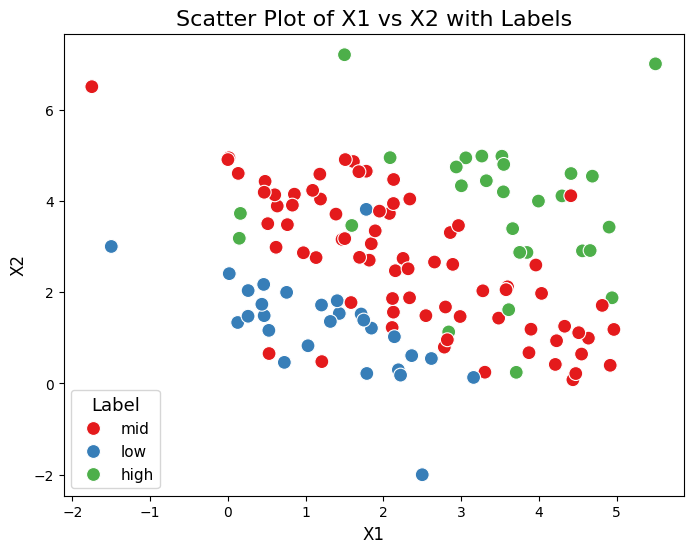

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='X1', y='X2', hue='label', data=df, palette='Set1', s=100)

# Customize plot
plt.title('Scatter Plot of X1 vs X2 with Labels', fontsize=16)
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.legend(title='Label', title_fontsize='13', fontsize='11')

# Show plot
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


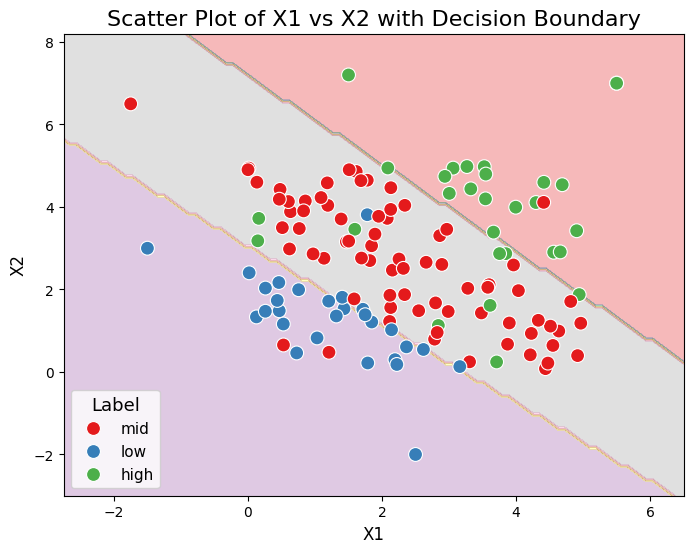

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Load your dataframe
df = pd.read_csv('synthetic_data_1.csv')

# Encode labels to numbers for Logistic Regression
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

# Train a logistic regression model
X = df[['X1', 'X2']]  # Features
y = df['label_encoded']  # Labels
model = LogisticRegression()
model.fit(X, y)

# Create a mesh grid for plotting decision boundaries
x_min, x_max = df['X1'].min() - 1, df['X1'].max() + 1
y_min, y_max = df['X2'].min() - 1, df['X2'].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict the class labels for each point in the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')

# Scatter plot
sns.scatterplot(x='X1', y='X2', hue='label', data=df, palette='Set1', s=100)

# Customize plot
plt.title('Scatter Plot of X1 vs X2 with Decision Boundary', fontsize=16)
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.legend(title='Label', title_fontsize='13', fontsize='11')

# Show plot
plt.show()
